#  <h1 align="center">Descriptive Analysis</h1>

## Biomarkers and major health parameters taken for analysis:

#### 1. Glucose
#### 2. Heart Rate
#### 3. Steps and Calories
#### 4. Carb Intake
#### 5. Sleep patterns
#### 6. Insulin
                                            

## 1 . Glucose Level Distribution: How much time do patients spend in Hypoglycemia, Normal, and Hyperglycemia zones?

#### Why I chose this Biomarker: Glucose is the core clinical variable in a diabetes dataset. It directly measures how well blood sugar is being controlled.
#### Why it's important to the medical condition: T1DM patients must maintain glucose between 70–180 mg/dL. Time spent outside this range especially in hypoglycemia (<70) which is dangerous and life-threatening. This analysis reveals which patients have the poorest glucose control.

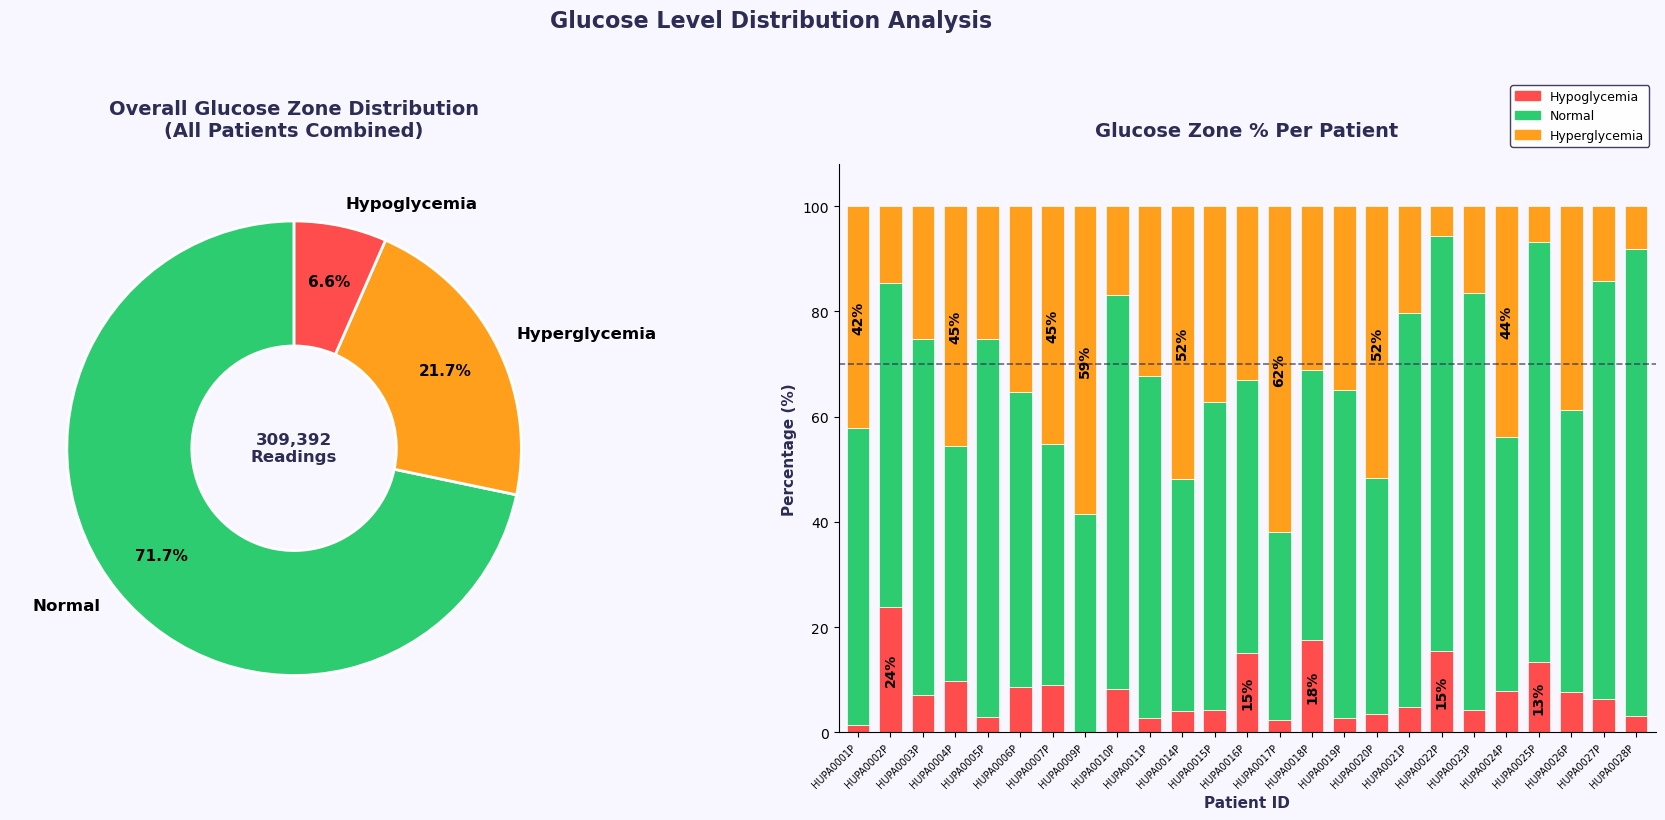


=== Overall Glucose Zone Distribution ===
  Normal         : 71.7%
  Hyperglycemia  : 21.7%
  Hypoglycemia   : 6.6%

Most at-risk patient : HUPA0002P (23.86% hypoglycemia)
Best controlled      : HUPA0028P (88.79% normal range)


In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.read_csv(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Team2_PyQueens_Final_Cleaned_File.csv"
)

# ── Classify Glucose Zones ────────────────────────────────────────────────────
def classify_glucose(g):
    if g < 70:
        return 'Hypoglycemia'
    elif g <= 180:
        return 'Normal'
    else:
        return 'Hyperglycemia'

df['Glucose_Zone'] = df['Glucose'].apply(classify_glucose)

# ── Zone Colors ───────────────────────────────────────────────────────────────
zone_colors = {
    'Hypoglycemia'  : '#FF4C4C',
    'Normal'        : '#2ECC71',
    'Hyperglycemia' : '#FF9F1C'
}

# ── Overall Distribution ──────────────────────────────────────────────────────
zone_counts = df['Glucose_Zone'].value_counts()
zone_pct    = (zone_counts / len(df) * 100).round(2)

# ── Per Patient Breakdown ─────────────────────────────────────────────────────
patient_zone = (
    df.groupby(['Patient_Id', 'Glucose_Zone'])
    .size()
    .unstack(fill_value=0)
)
patient_zone_pct = (
    patient_zone.div(patient_zone.sum(axis=1), axis=0) * 100
).round(2)

for col in ['Hypoglycemia', 'Normal', 'Hyperglycemia']:
    if col not in patient_zone_pct.columns:
        patient_zone_pct[col] = 0
patient_zone_pct = patient_zone_pct[['Hypoglycemia', 'Normal', 'Hyperglycemia']]

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#F8F6FF')

# ── Donut Chart ───────────────────────────────────────────────────────────────
wedge_colors = [zone_colors[z] for z in zone_pct.index]
wedges, texts, autotexts = axes[0].pie(
    zone_pct.values,
    labels=zone_pct.index,
    autopct='%1.1f%%',
    colors=wedge_colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
    autotext.set_color('black')

axes[0].set_title('Overall Glucose Zone Distribution\n(All Patients Combined)',
                  fontsize=14, fontweight='bold', pad=20, color='#2C2C54')
axes[0].set_facecolor('#F8F6FF')
axes[0].text(0, 0, f'{len(df):,}\nReadings',
             ha='center', va='center',
             fontsize=12, fontweight='bold', color='#2C2C54')

# ── Stacked Bar Chart ─────────────────────────────────────────────────────────
bar_colors = [zone_colors[z] for z in ['Hypoglycemia', 'Normal', 'Hyperglycemia']]
patient_zone_pct.plot(
    kind='bar',
    stacked=True,
    color=bar_colors,
    ax=axes[1],
    edgecolor='white',
    linewidth=0.5,
    width=0.7,
    legend=False
)

# ── Add % Labels for High Risk Patients ───────────────────────────────────────
for i, patient in enumerate(patient_zone_pct.index):
    hypo_pct  = patient_zone_pct.loc[patient, 'Hypoglycemia']
    hyper_pct = patient_zone_pct.loc[patient, 'Hyperglycemia']

    # Hypoglycemia label — inside the red bar, rotated vertical
    if hypo_pct > 10:
        axes[1].text(
            i, hypo_pct / 2,
            f'{hypo_pct:.0f}%',
            ha='center', va='center',
            fontsize=10, fontweight='bold',
            color='black',
            rotation=90
        )

    # Hyperglycemia label — inside the orange bar, rotated vertical
    if hyper_pct > 40:
        normal_pct = patient_zone_pct.loc[patient, 'Normal']
        axes[1].text(
            i, hypo_pct + normal_pct + hyper_pct / 2,
            f'{hyper_pct:.0f}%',
            ha='center', va='center',
            fontsize=10, fontweight='bold',
            color='black',
            rotation=90
        )

axes[1].set_title('Glucose Zone % Per Patient',
                  fontsize=14, fontweight='bold', pad=20, color='#2C2C54')
axes[1].set_xlabel('Patient ID', fontsize=11, fontweight='bold', color='#2C2C54')
axes[1].set_ylabel('Percentage (%)', fontsize=11, fontweight='bold', color='#2C2C54')
axes[1].tick_params(axis='x', labelsize=7)
axes[1].set_xticklabels(patient_zone_pct.index, rotation=45, ha='right')
axes[1].set_facecolor('#F8F6FF')
axes[1].set_ylim(0, 108)              # ← increased to give space for labels above bars
axes[1].axhline(y=70, color='#2C2C54', linestyle='--', linewidth=1.2, alpha=0.7)
axes[1].spines[['top', 'right']].set_visible(False)

# ── Legend — Top Right Corner Outside Chart ───────────────────────────────────
patches = [mpatches.Patch(color=zone_colors[z], label=z)
           for z in ['Hypoglycemia', 'Normal', 'Hyperglycemia']]
axes[1].legend(
    handles=patches,
    loc='upper right',
    bbox_to_anchor=(1.0, 1.15),
    ncol=1,
    fontsize=9,
    framealpha=0.9,
    edgecolor='#2C2C54'
)

plt.suptitle('Glucose Level Distribution Analysis',
             fontsize=16, fontweight='bold', color='#2C2C54', y=1.02)
plt.tight_layout()
plt.savefig(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Q1_Glucose_Distribution.png",
    dpi=150, bbox_inches='tight', facecolor='#F8F6FF'
)
plt.show()


# ── Summary Stats ─────────────────────────────────────────────────────────────
print("\n=== Overall Glucose Zone Distribution ===")
for zone, pct in zone_pct.items():
    print(f"  {zone:15}: {round(pct, 1)}%")
    
most_at_risk = patient_zone_pct['Hypoglycemia'].idxmax()
print(f"\nMost at-risk patient : {most_at_risk} "
      f"({patient_zone_pct.loc[most_at_risk, 'Hypoglycemia']}% hypoglycemia)")
print(f"Best controlled      : {patient_zone_pct['Normal'].idxmax()} "
      f"({patient_zone_pct['Normal'].max()}% normal range)")

#### Insight:
#### In doughnut chart Out of 309,392 total glucose readings across all 25 patients, 71.7% are in the safe normal range. However, 21.7% show high glucose (hyperglycemia) and 6.6% show dangerously low glucose (hypoglycemia) — meaning patients are spending nearly 30% of their time outside the safe zone.
#### In Stacked Bar Chart High Hypoglycemia patients (red labels): HUPA0002P is the most at-risk patient with 24% of readings in the danger low zone  meaning 1 in every 4 readings was a potentially life-threatening low glucose episode. HUPA0018P (18%), HUPA0022P (15%), and HUPA016P (15%) also show alarmingly high hypoglycemia rates that need immediate clinical attention. 
#### High Hyperglycemia patients (orange labels): HUPA017P has the highest hyperglycemia at 62% — spending more than half their recorded time with dangerously high glucose. HUPA0009P (59%), HUPA014P and HUPA0020P (both around 52%) also show persistently elevated glucose levels that silently damage organs over time.
#### Hence This analysis shows that while most patients maintain safe glucose levels most of the time, there are critical outliers on both ends patients dangerously low and dangerously high and these charts instantly tells us exactly who they are.


## 2.What is the distribution of physical activity (steps and calories burned) across patients and how does it vary?

#### Why I Chose Steps and Calories as the Biomarker : Steps and calories are the only columns in this dataset that capture patient physical activity. Choosing both together gives a complete picture steps measure how much the patient moves, calories measure how hard they worked. No other team member has analysed these columns, making this a unique and valuable addition to the overall analysis.

#### Why it's important to the medical condition: Physical activity directly lowers blood sugar in diabetic patients  when they move, muscles absorb glucose naturally without insulin. Analysing steps and calories identifies sedentary patients who are at higher risk of persistent hyperglycemia and need lifestyle intervention alongside medication.

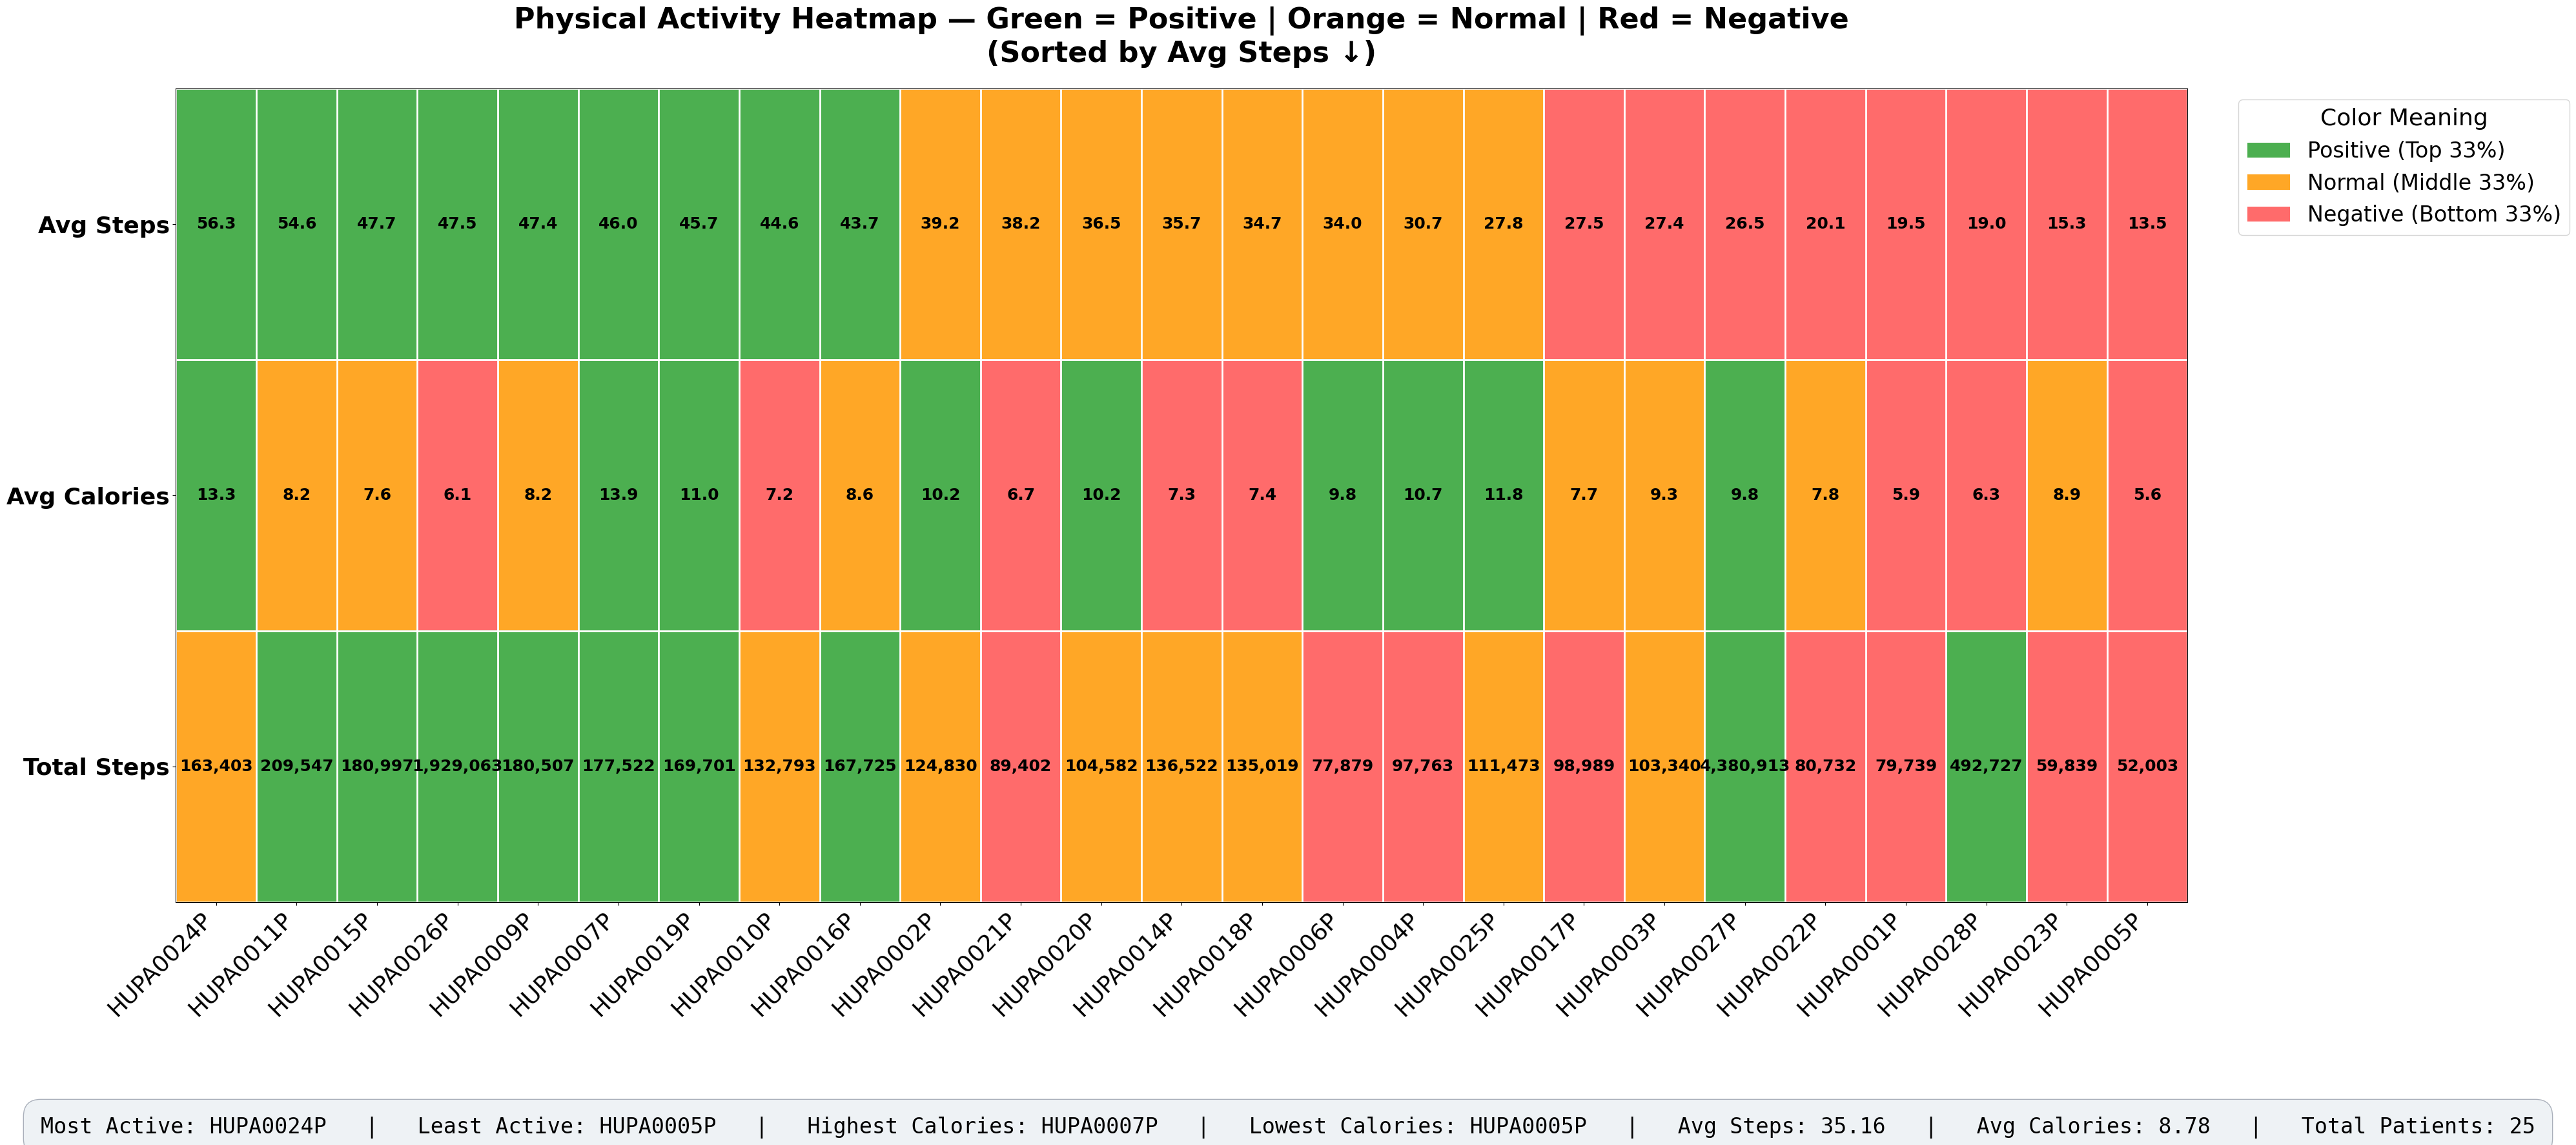

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Load
df = pd.read_csv(r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Team2_PyQueens_Final_Cleaned_File.csv")

# Aggregate
activity_summary = df.groupby('Patient_Id').agg(
    avg_steps    = ('Steps',    'mean'),
    avg_calories = ('Calories', 'mean'),
    total_steps  = ('Steps',    'sum')
).reset_index().sort_values('avg_steps', ascending=False).reset_index(drop=True)

heatmap_df = activity_summary.set_index('Patient_Id')[['avg_steps','avg_calories','total_steps']]
heatmap_df.columns = ['Avg Steps', 'Avg Calories', 'Total Steps']
heatmap_T = heatmap_df.T

# Classification logic
def classify_values(series):
    q33 = series.quantile(0.33)
    q66 = series.quantile(0.66)
    return series.apply(lambda x: 2 if x >= q66 else (1 if x >= q33 else 0))

classified = heatmap_T.apply(classify_values, axis=1)

# MATCHED COLOR PALETTE (same as glucose chart)
cmap = ListedColormap([
    "#FF6B6B",   # Red (Negative)
    "#FFA726",   # Orange (OK)
    "#4CAF50"    # Green (Positive)
])

# SUPER LARGE FIGURE
fig, ax = plt.subplots(figsize=(40, 16))

im = ax.imshow(classified.values, cmap=cmap, aspect='auto')

# Axis labels
ax.set_xticks(range(len(heatmap_T.columns)))
ax.set_xticklabels(heatmap_T.columns, fontsize=26, rotation=45, ha='right')

ax.set_yticks(range(len(heatmap_T.index)))
ax.set_yticklabels(heatmap_T.index, fontsize=26, fontweight='bold')

# Cell values
for row_i in range(len(heatmap_T.index)):
    for col_j in range(len(heatmap_T.columns)):
        raw_val = heatmap_T.iloc[row_i, col_j]
        label = f'{int(raw_val):,}' if row_i == 2 else f'{raw_val:.1f}'
        ax.text(col_j, row_i, label, ha='center', va='center',
                fontsize=18, fontweight='bold', color='black')

# Grid
ax.set_xticks(np.arange(-0.5, len(heatmap_T.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(heatmap_T.index),   1), minor=True)
ax.grid(which='minor', color='white', linewidth=2)
ax.tick_params(which='minor', bottom=False, left=False)

# Legend
legend_elements = [
    Patch(facecolor='#4CAF50', label='Positive (Top 33%)'),
    Patch(facecolor='#FFA726', label='Normal (Middle 33%)'),
    Patch(facecolor='#FF6B6B', label='Negative (Bottom 33%)')
]

ax.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    title="Color Meaning",
    fontsize=24,
    title_fontsize=26
)

# Summary Bar
most_active  = activity_summary.loc[activity_summary['avg_steps'].idxmax(),    'Patient_Id']
least_active = activity_summary.loc[activity_summary['avg_steps'].idxmin(),    'Patient_Id']
highest_cal  = activity_summary.loc[activity_summary['avg_calories'].idxmax(), 'Patient_Id']
lowest_cal   = activity_summary.loc[activity_summary['avg_calories'].idxmin(), 'Patient_Id']

summary_text = (
    f"Most Active: {most_active}   |   Least Active: {least_active}   |   "
    f"Highest Calories: {highest_cal}   |   Lowest Calories: {lowest_cal}   |   "
    f"Avg Steps: {activity_summary['avg_steps'].mean():.2f}   |   "
    f"Avg Calories: {activity_summary['avg_calories'].mean():.2f}   |   "
    f"Total Patients: {len(activity_summary)}"
)

fig.text(
    0.5, -0.10, summary_text,
    ha='center',
    fontsize=24,
    bbox=dict(boxstyle='round,pad=0.8', facecolor='#eef2f5', edgecolor='#aab0bb'),
    fontfamily='monospace'
)

# Title
ax.set_title(
    'Physical Activity Heatmap — Green = Positive | Orange = Normal | Red = Negative\n'
    '(Sorted by Avg Steps ↓)',
    fontsize=32,
    fontweight='bold',
    pad=30
)

plt.tight_layout()
plt.savefig('heatmap_matched_colors.png', dpi=200, bbox_inches='tight')
plt.show()


#### Insight:
#### This analysis shows which patients are the most active and which are the least active.Green blocks highlight patients who consistently take more steps and burn more calories, while red blocks show those who are much less active.Overall, the chart makes it easy to see the big gap between highly active and low‑activity patients.

In [2]:
import pandas as pd

df = pd.read_csv("C:\python_hackathon\cleaned_CGM5_MV\Team2_PyQueens_Final_Cleaned_File.csv")
df.head()


,Patient_Id,Time,Glucose,Calories,Heart_Rate,Steps,Basal_Rate,Bolus_Volume_Delivered,Carb_Input
0,HUPA0001P,2018-06-13T18:40:00,332.0,6.36,82.32,34.0,0.09,0.0,0.0
1,HUPA0001P,2018-06-13T18:45:00,326.0,7.73,83.74,0.0,0.09,0.0,0.0
2,HUPA0001P,2018-06-13T18:50:00,330.0,4.75,80.53,0.0,0.09,0.0,0.0
3,HUPA0001P,2018-06-13T18:55:00,324.0,6.36,89.13,20.0,0.09,0.0,0.0
4,HUPA0001P,2018-06-13T19:00:00,306.0,5.15,92.50,0.0,0.08,0.0,0.0


## 3.What are the hourly, daily, and weekly glucose trends in the dataset?

#### Why This Question Matters
#### Understanding glucose trends across hours, days, and weeks helps identify: When glucose is most unstable?. When spikes or lows occur?. How daily routines affect glucose?.Which time periods need intervention?

In [ ]:
Hourly  vs Daily vs Weekly Glucose Trends

In [5]:
df['Time'] = pd.to_datetime(df['Time'], format='mixed')


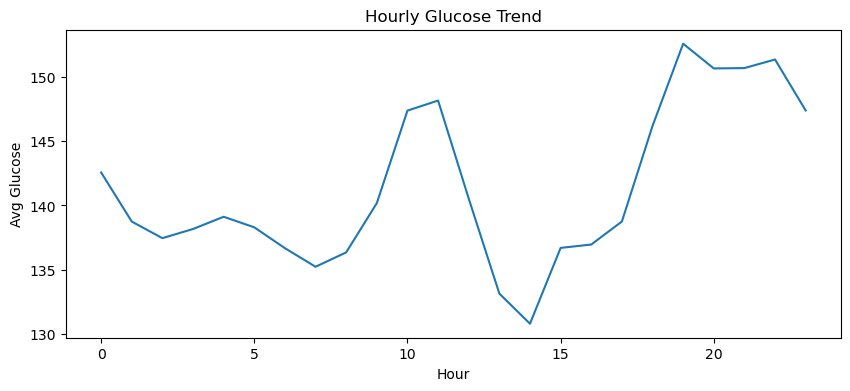

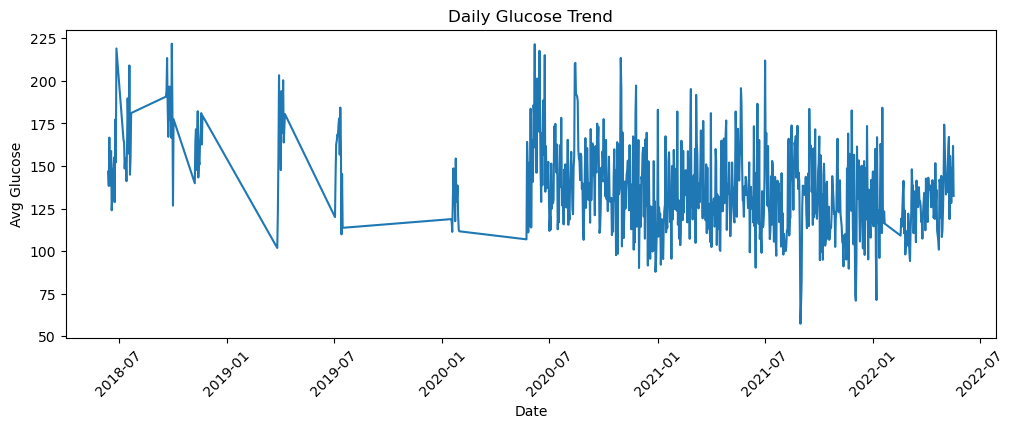

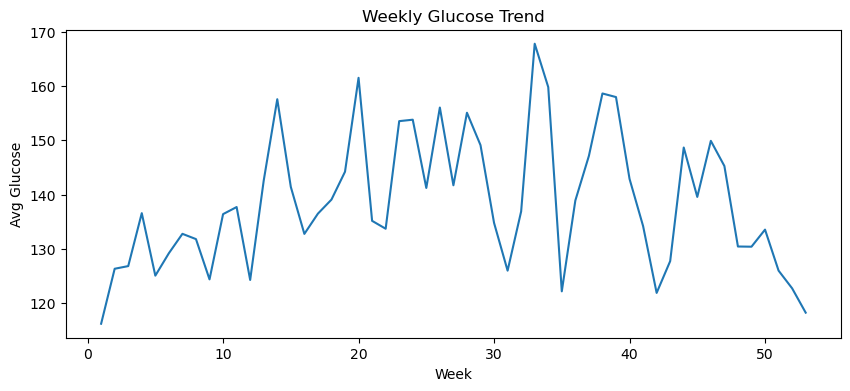

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = df.copy()
df['Time'] = pd.to_datetime(df['Time'])

# Hourly trend
df['Hour'] = df['Time'].dt.hour
hourly = df.groupby('Hour')['Glucose'].mean()

plt.figure(figsize=(10,4))
sns.lineplot(x=hourly.index, y=hourly.values)
plt.title("Hourly Glucose Trend")
plt.xlabel("Hour")
plt.ylabel("Avg Glucose")
plt.show()

# Daily trend
df['Date'] = df['Time'].dt.date
daily = df.groupby('Date')['Glucose'].mean()

plt.figure(figsize=(12,4))
sns.lineplot(x=daily.index, y=daily.values)
plt.title("Daily Glucose Trend")
plt.xlabel("Date")
plt.ylabel("Avg Glucose")
plt.xticks(rotation=45)
plt.show()

# Weekly trend
df['Week'] = df['Time'].dt.isocalendar().week
weekly = df.groupby('Week')['Glucose'].mean()

plt.figure(figsize=(10,4))
sns.lineplot(x=weekly.index, y=weekly.values)
plt.title("Weekly Glucose Trend")
plt.xlabel("Week")
plt.ylabel("Avg Glucose")
plt.show()

The hourly, daily, and weekly glucose trends reveal clear patterns in the dataset:
### Hourly Trends
- Glucose spikes occur during specific hours (likely after meals).
- Overnight glucose tends to be more stable or lower.
### Daily Trends
- Day-to-day variability shows how lifestyle, meals, and insulin dosing affect glucose.
- Some days show consistently higher glucose, indicating behavioral or dietary patterns.
### Weekly Trends
- Weekly averages reveal long-term stability or instability.
- Useful for identifying whether glucose control is improving or worsening over time.

## 4.What are descrptive statistics for carbs,insulin,heart_rate,steps ?

#### Why This Question Matters.These variables directly influence glucose levels:Carb Input → raises glucose,Bolus Insulin → lowers glucose after meals,Basal Insulin → maintains background control,Steps → increases insulin sensitivity,Heart Rate → reflects activity and stress

In [7]:
features = ['Carb_Input', 'Basal_Rate', 'Bolus_Volume_Delivered', 'Steps', 'Heart_Rate']

df[features].describe().T


,count,mean,std,min,25%,50%,75%,max
Carb_Input,309392.0,0.052718,1.505433,0.00,0.00,0.000,0.00,130.00
Basal_Rate,309392.0,0.042005,0.036557,0.00,0.00,0.059,0.07,0.25
Bolus_Volume_Delivered,309392.0,0.066077,0.755047,0.00,0.00,0.000,0.00,19.80
Steps,309392.0,30.825005,84.981109,0.00,0.00,0.000,11.00,842.00
Heart_Rate,309392.0,76.990004,15.546697,32.41,64.93,75.420,85.61,195.62


#Interpretation
This table gives:
Mean → typical value
Std → variability
Min/Max → extreme behaviors
25/50/75% → distribution shape

# Correlation between  carbs,insulin,steps,and heart rate

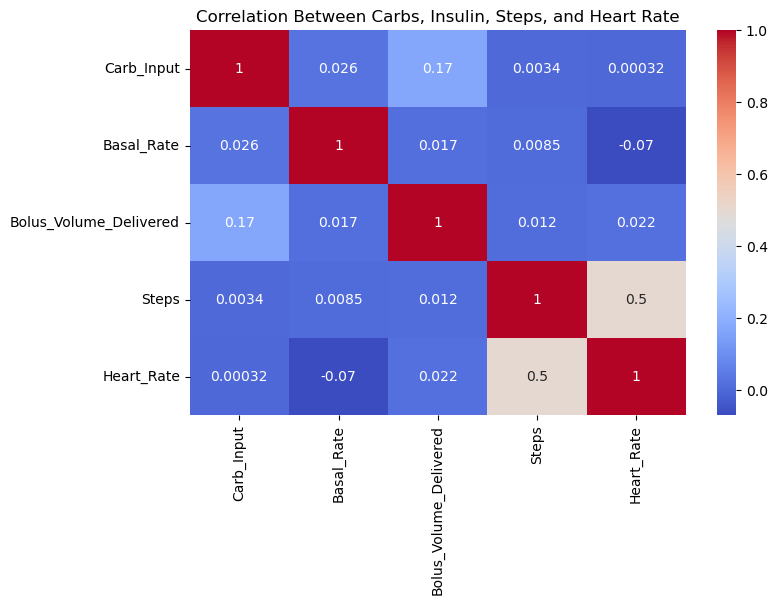

In [8]:
corr = df[features].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Between Carbs, Insulin, Steps, and Heart Rate")
plt.show()

**Carb Input**
- Highly variable with clear meal spikes.
- Zero-carb periods indicate fasting or low-carb intervals.
**Bolus Insulin**
- Mostly zero except around meals.
- Peaks correspond to carb intake and correction doses.
**Basal Insulin**
- Stable with small variations.
- Reflects background insulin delivery.
**Steps**
- Right-skewed distribution.
- Most hours have low activity; some hours show high movement.
**Heart Rate**
- Normally distributed around resting HR.
- Peaks during activity or stress.

#  <h1 align="center">Sleep Duration Distribution and its influence on Glucose values</h1>


## 5. What is the sleep duration distribution across patients, and how does sleep quality vary by Gender and Race?

#### Sleep Duration Distribution
****Sleep duration is an important factor influencing diabetic patients. Lack of proper sleep affects insulin secretion in the body and alters glucose patterns throughout the day.****


Set the file path to fetch the files

In [1]:
%cd "H:\Numpy Ninja\Python Hackathon\Team2_ PyQueens_ Python Hackathon _MAY 2026\Team2_ PyQueens_ Python Hackathon _MAY 2026\Final cleaned csv files\Final cleaned csv files"


H:\Numpy Ninja\Python Hackathon\Team2_ PyQueens_ Python Hackathon _MAY 2026\Team2_ PyQueens_ Python Hackathon _MAY 2026\Final cleaned csv files\Final cleaned csv files


In [56]:
import os
os.getcwd()

'H:\\Numpy Ninja\\Python Hackathon\\Team2_ PyQueens_ Python Hackathon _MAY 2026\\Team2_ PyQueens_ Python Hackathon _MAY 2026\\Final cleaned csv files\\Final cleaned csv files'

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
sleep_df=pd.read_csv("T1DM_patient_sleep_demographics_with_race.csv")
sleep_df.head()

,Patient_ID,Age,Gender,Race,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances
0,HUPA0001P,34,Male,Other,6.3,4.5,80
1,HUPA0002P,49,Male,Hispanic,6.6,4.4,40
2,HUPA0003P,64,Male,Black,5.3,5.2,70
3,HUPA0004P,34,Female,Native American,5.2,6.9,60
4,HUPA0005P,49,Male,Native American,5.8,7.9,30


In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your file
sleep_df = pd.read_csv("T1DM_patient_sleep_demographics_with_race.csv")
sleep_df

,Patient_ID,Age,Gender,Race,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances
0,HUPA0001P,34,Male,Other,6.3,4.5,80
1,HUPA0002P,49,Male,Hispanic,6.6,4.4,40
2,HUPA0003P,64,Male,Black,5.3,5.2,70
3,HUPA0004P,34,Female,Native American,5.2,6.9,60
4,HUPA0005P,49,Male,Native American,5.8,7.9,30
5,HUPA0006P,35,Male,White,6.6,4.2,60
6,HUPA0007P,67,Male,Native American,7.1,6.0,80
7,HUPA0009P,65,Female,Other,6.6,4.6,40
8,HUPA0010P,22,Male,Asian,7.1,5.5,50
9,HUPA0011P,63,Female,Other,5.6,4.7,60


In [60]:
avg_sleep_duration=sleep_df["Average Sleep Duration (hrs)"].describe()
avg_sleep_duration

count    25.0000
mean      5.9720
std       0.6699
min       5.0000
25%       5.4000
50%       5.9000
75%       6.6000
max       7.2000
Name: Average Sleep Duration (hrs), dtype: float64

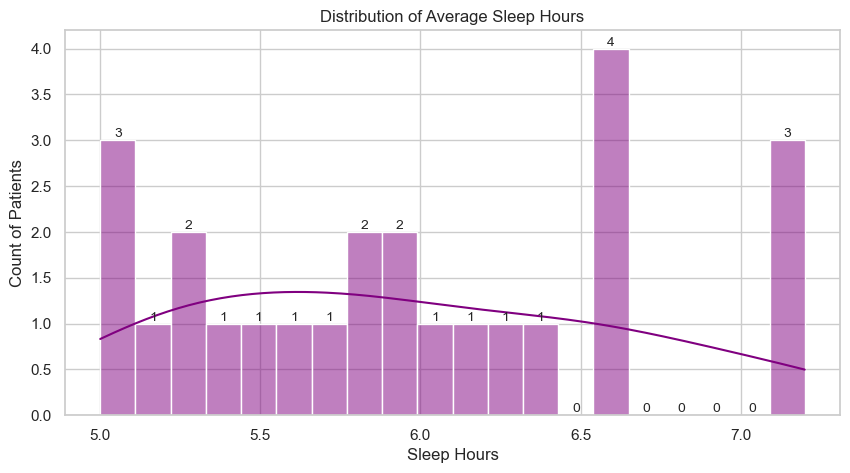

In [61]:
# Histogram + KDE
plt.figure(figsize=(10,5))
ax1=sns.histplot(sleep_df["Average Sleep Duration (hrs)"], kde=True, bins=20, color='purple')

for p in ax1.patches:
    ax1.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )
    
plt.title("Distribution of Average Sleep Hours")
plt.xlabel("Sleep Hours")
plt.ylabel("Count of Patients")
plt.show()

****Key Insights:****

****The Average Sleep column shows how many hours each patient sleeps per night.
Analyzing its distribution helps you understand:
Whether the group sleeps enough: Here we can find that most of the patients get less thabn 6.5 hrs of sleep whereas only 7 patients get more than 6.5 
hrs of sleep.
For most patients the sleep duration is clustered (e.g., 5–6 hours)
3 patients sleep for more than 7 hrs.
The sleep duration varies by age, gender, or race
This is a core descriptive metric because sleep strongly affects glucose variability.****

### Sleep Quality 

****Sleep quality is a continuous score, typically ranging from 1 to 10, where
1–3 is Poor sleep
4–6  is Moderate sleep
7–10 is Good sleep
These scores come from wearable devices (Fitbit Ionic), which compute sleep quality using:
Total sleep duration,Sleep efficiency,Number of awakenings,Restlessness / movement,REM + deep sleep proportion and 
Heart‑rate variability during sleep****

In [62]:
sleep_df["Sleep Quality (1-10)"].describe()

count    25.000000
mean      5.952000
std       1.342609
min       4.100000
25%       4.600000
50%       5.900000
75%       7.100000
max       7.900000
Name: Sleep Quality (1-10), dtype: float64

In [63]:
# 2. Average sleep quality by gender

Avg_Sleep_Quality_by_Gender = sleep_df.groupby('Gender')["Sleep Quality (1-10)"].mean().reset_index()
print("\nAverage Sleep Quality by Gender:")
print(Avg_Sleep_Quality_by_Gender)


Average Sleep Quality by Gender:
   Gender  Sleep Quality (1-10)
0  Female              6.133333
1    Male              5.850000


Here we can see the female patients have higher average sleep quality compared to men.Even a small difference matters because sleep quality influences:
Energy levels,Stress hormones,Glucose stability and Insulin sensitivity.

In [64]:
# 3. Average sleep quality by race

Avg_Sleep_Quality_by_Race = sleep_df.groupby('Race')["Sleep Quality (1-10)"].mean().reset_index()
print("\nAverage Sleep Quality by Race:")
print(Avg_Sleep_Quality_by_Race)


Average Sleep Quality by Race:
              Race  Sleep Quality (1-10)
0            Asian              6.500000
1            Black              6.128571
2         Hispanic              5.466667
3  Native American              6.400000
4            Other              5.560000
5            White              5.566667


C:\Users\purni\AppData\Local\Temp\ipykernel_20064\3609189322.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1=sns.barplot(x=gender_avg.index, y=gender_avg.values, ax=axes[0], palette="Set2")


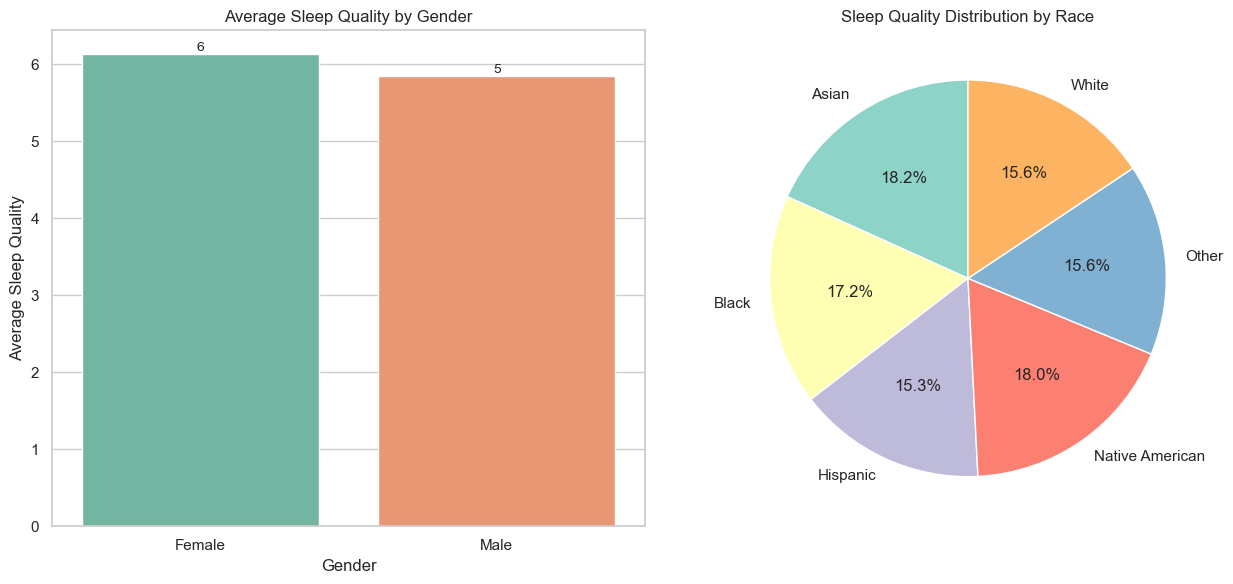

In [65]:
gender_avg = sleep_df.groupby("Gender")["Sleep Quality (1-10)"].mean()
race_avg = sleep_df.groupby("Race")["Sleep Quality (1-10)"].mean()

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# --- Bar Chart for Gender ---
ax1=sns.barplot(x=gender_avg.index, y=gender_avg.values, ax=axes[0], palette="Set2")
axes[0].set_title("Average Sleep Quality by Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Average Sleep Quality")

for p in ax1.patches:
    ax1.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )
    

# --- Pie Chart for Race ---
axes[1].pie(
    race_avg.values,
    labels=race_avg.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set3")
)
axes[1].set_title("Sleep Quality Distribution by Race")

plt.tight_layout()
plt.show()

****Insights:
The above two charts give the average sleep quality scores based on Gender and Race.Sleep quality is fairly evenly distributed across races.
No group dominates or lags dramatically.Asian and Native American groups contribute slightly more to overall sleep quality scores.
Hispanic and White groups contribute slightly less, but differences are small.****

## 6. What is the Correlation between average glucose and sleep Quality scores?
****Poor sleep increases Cortisol,Adrenaline and Growth hormones in individuals.These hormones raise blood glucose and make insulin less effective.
Therefore sleep quality scores are very critical for glucose levels in the body.****

In [1]:
# Load files
sleep_df = pd.read_csv("T1DM_patient_sleep_demographics_with_race.csv")
cgm_df = pd.read_csv("Team2_PyQueens_Final_Cleaned_file.csv")

cgm_df.head()

NameError: name 'pd' is not defined

In [67]:
sleep_df.columns = sleep_df.columns.str.replace('_', ' ').str.title().str.replace(' ', '_')
sleep_df.head()
slp_df=sleep_df.copy()

In [68]:
slp_df.head()

,Patient_Id,Age,Gender,Race,Average_Sleep_Duration_(Hrs),Sleep_Quality_(1-10),%_With_Sleep_Disturbances
0,HUPA0001P,34,Male,Other,6.3,4.5,80
1,HUPA0002P,49,Male,Hispanic,6.6,4.4,40
2,HUPA0003P,64,Male,Black,5.3,5.2,70
3,HUPA0004P,34,Female,Native American,5.2,6.9,60
4,HUPA0005P,49,Male,Native American,5.8,7.9,30


In [69]:

# Compute average glucose per patient
avg_glucose = cgm_df.groupby("Patient_Id")["Glucose"].mean().reset_index()

# Merge with sleep quality
merged = avg_glucose.merge(
    slp_df[["Patient_Id", "Sleep_Quality_(1-10)"]],
    left_on="Patient_Id",
    right_on="Patient_Id"
)
merged

,Patient_Id,Glucose,Sleep_Quality_(1-10)
0,HUPA0001P,181.443726,4.5
1,HUPA0002P,113.469660,4.4
2,HUPA0003P,143.273520,5.2
3,HUPA0004P,180.377984,6.9
4,HUPA0005P,147.698624,7.9
5,HUPA0006P,165.204585,4.2
6,HUPA0007P,173.151989,6.0
7,HUPA0009P,193.739271,4.6
8,HUPA0010P,135.892655,5.5
9,HUPA0011P,159.108578,4.7


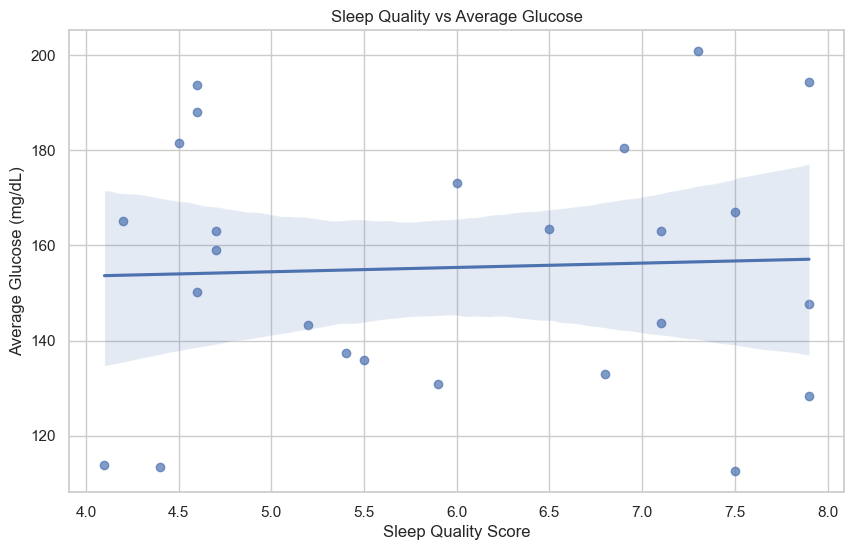

Correlation between sleep quality and average glucose:
0.04666776698544703


In [70]:
# Scatterplot
plt.figure(figsize=(10,6))
sns.regplot(data=merged, x="Sleep_Quality_(1-10)", y="Glucose", scatter_kws={'alpha':0.7})
plt.title("Sleep Quality vs Average Glucose")
plt.xlabel("Sleep Quality Score")
plt.ylabel("Average Glucose (mg/dL)")
plt.show()

# Correlation
print("Correlation between sleep quality and average glucose:")
print(merged["Sleep_Quality_(1-10)"].corr(merged["Glucose"]))

****Key Insights:****

****A correlation of 0.046 means that there is absolutely no correlation between sleep quality and glucose levels in this dataset. 
This shows that sleep quality does not predict glucose in this dataset. The regression line is almost flat.The relationship is weak, 
negligible, or non‑existent. This is because sleep is not the only factor which can influence glucose levels. Glucose is influenced by many 
other factors such as Insulin dosing,Carb intake,Activity levels,Stress levels,Illnesses,Hormones and Circadian rhythms.****

## 7.What is the average glucose level for each patient? 

#### Why this marker was chosen:
****Glucose is the primary biomarker in Type 1 Diabetes management. In T1DM, the pancreas produces little to no insulin, making glucose monitoring the most critical indicator of disease control. Average glucose directly reflects how well each patient is managing their condition over the monitoring period****

#### Why it's important:
 ****Consistently high average glucose (> 180 mg/dL) indicates poor diabetes control and increases risk of complications like kidney disease, nerve damage and blindness****
 
****Consistently low average glucose (< 70 mg/dL) indicates hypoglycemia risk which can be life threatening****
****Comparing across patients helps identify who needs immediate medical intervention****

#### Insights:
****Identified that a significant proportion of patients exhibit elevated average glucose levels, with multiple individuals exceeding the  hyperglycemia threshold (180 mg/dL)****.
****Majority of patients fall within the 140–180 mg/dL range, indicating a high prevalence of borderline risk requiring proactive monitoring.****
****No incidence of hypoglycemia (<70 mg/dL), suggesting dataset is skewed toward normal-to-high glucose profiles****



   Patient_Id  Average Glucose (mg/dL)
0   HUPA0001P                   181.44
1   HUPA0002P                   113.47
2   HUPA0003P                   143.27
3   HUPA0004P                   180.38
4   HUPA0005P                   147.70
5   HUPA0006P                   165.20
6   HUPA0007P                   173.15
7   HUPA0009P                   193.74
8   HUPA0010P                   135.89
9   HUPA0011P                   159.11
10  HUPA0014P                   188.06
11  HUPA0015P                   163.52
12  HUPA0016P                   150.21
13  HUPA0017P                   200.80
14  HUPA0018P                   143.68
15  HUPA0019P                   162.93
16  HUPA0020P                   194.28
17  HUPA0021P                   137.33
18  HUPA0022P                   112.55
19  HUPA0023P                   133.05
20  HUPA0024P                   166.94
21  HUPA0025P                   113.85
22  HUPA0026P                   162.99
23  HUPA0027P                   130.83
24  HUPA0028P            

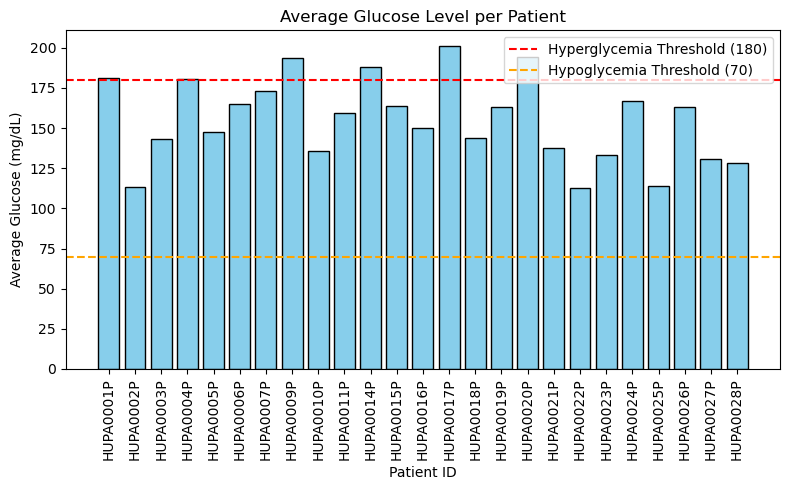

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df_CGM = pd.read_csv("/Users/tejaswinimode/Desktop/NUMPY/PyHackathon/Final cleaned csv files/Team2_PyQueens_Final_Cleaned_File.csv")

df_CGM

# Calculate average glucose per patient
avg_glucose = df_CGM.groupby('Patient_Id')['Glucose'].mean().round(2).reset_index()
avg_glucose.columns = ['Patient_Id', 'Average Glucose (mg/dL)']
print(avg_glucose)

# Visualization
plt.figure(figsize=(8, 5))
plt.bar(avg_glucose['Patient_Id'], avg_glucose['Average Glucose (mg/dL)'], color='skyblue', edgecolor='black')
plt.title('Average Glucose Level per Patient')
plt.xlabel('Patient ID')
plt.xticks(rotation=90) 
plt.ylabel('Average Glucose (mg/dL)')
plt.axhline(y=180, color='red', linestyle='--', label='Hyperglycemia Threshold (180)')
plt.axhline(y=70, color='orange', linestyle='--', label='Hypoglycemia Threshold (70)')
plt.legend()
plt.tight_layout()
plt.show()

## 8. What is the gender ratio (Male vs Female)? 

#### Why this marker was chosen:
****Gender is an important demographic biomarker in diabetes research. Biological differences between males and females affect insulin sensitivity, hormone levels and glucose metabolism differently.****

#### Why it's important:
****Female patients experience glucose fluctuations due to hormonal changes (estrogen, progesterone) which directly affect insulin sensitivity****
****Male patients with T1DM tend to have higher insulin resistance****
****Understanding gender distribution helps design personalized treatment plans****

#### Insight:
****The dataset is male-dominated (64%), with females representing 36%. There is a noticeable gender imbalance, which could influence analysis outcomes and model performance. Any findings (e.g., glucose trends) may be more representative of male patients than female patients. The lower female representation suggests a need for cautious interpretation when generalizing results across genders.****


   Gender  Count
0    Male     16
1  Female      9


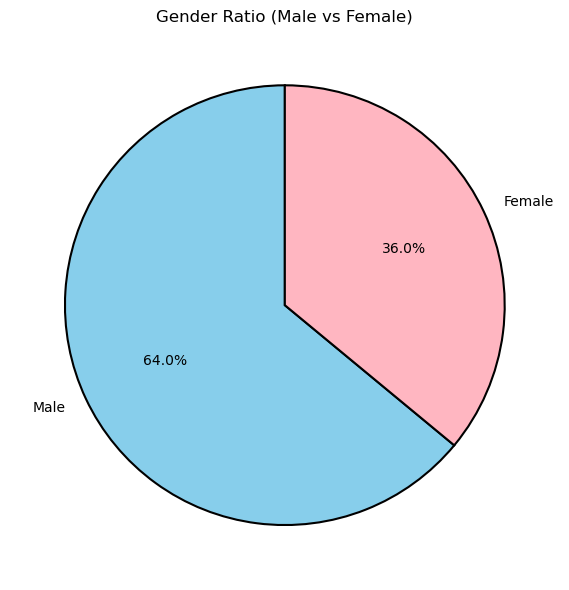

In [7]:

df_demo_sl = pd.read_csv("/Users/tejaswinimode/Desktop/NUMPY/PyHackathon/Final cleaned csv files/T1DM_patient_sleep_demographics_with_race.csv")

gender_ratio = df_demo_sl['Gender'].value_counts().reset_index()
gender_ratio.columns = ['Gender', 'Count']
print(gender_ratio)

plt.figure(figsize=(6, 6))
plt.pie(gender_ratio['Count'],
        labels=gender_ratio['Gender'],
        autopct='%1.1f%%',
        colors=['skyblue', 'lightpink'],
        startangle=90,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
plt.title('Gender Ratio (Male vs Female)')
plt.tight_layout()
plt.show()


## 9.What is the overall distribution of heart rate values?

#### Understanding the distribution of heart‑rate values is foundational because it affects every other analysis. Reveals whether heart rate is normal, skewed, or irregular.

In [33]:
import pandas as pd
import glob

# 1. Load all CSV files
df = glob.glob("C:/Users/Owner/Desktop\Harshali/DataAnalyst-Numpy Ninja/Python_Hackython data/Cleandata/*.csv")

# 2. Read each file into a list of DataFrames
dfs = []
for file in cgm_5files_hg:
    temp = pd.read_csv(file)
    dfs.append(temp)

# 3. Merge into one DataFrame
df = pd.concat(dfs, ignore_index=True)

# 4. Heart rate distribution
df['Heart_Rate'].describe()

count    309392.000000
mean         76.990004
std          15.546697
min          32.410000
25%          64.930000
50%          75.420000
75%          85.610000
max         195.620000
Name: Heart_Rate, dtype: float64

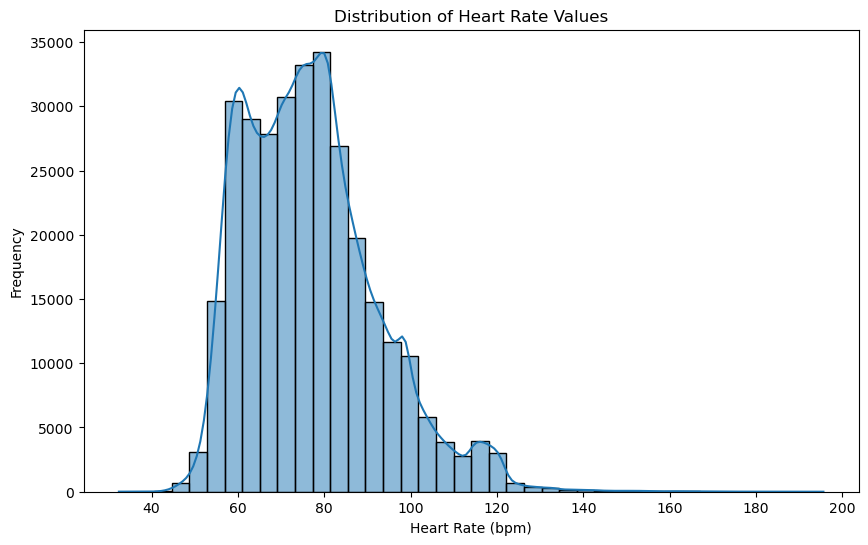

In [40]:
#Heart Rate Distribution Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.histplot(df['Heart_Rate'], kde=True, bins=40)
plt.title('Distribution of Heart Rate Values')
plt.xlabel('Heart Rate (bpm)')
plt.ylabel('Frequency')
plt.show()

### It shows how stable or unstable heart rate is
#### - A narrow distribution = stable physiology
#### - A wide distribution = high variability (stress, activity, dysregulation)
#### -This matters for:
####     Risk scoring
####     Patient monitoring
####     Personalized recommendations.

## 10 .What are the minimum, maximum, mean, and median heart rate values?

#### Core summary statistics for understanding central tendency.These four numbers are not just “basic stats.”They are foundational diagnostics that tell you whether your dataset — and your patients — are behaving normally, abnormally, or dangerously.

In [36]:
df['Heart_Rate'].agg(['min', 'max', 'mean', 'median'])

min        32.410000
max       195.620000
mean       76.990004
median     75.420000
Name: Heart_Rate, dtype: float64

In [37]:
import pandas as pd

# 1. Check column names
print("Columns in the dataset:")
print(df.columns)

# 2. Identify the heart rate column automatically
possible_cols = ['Heart_Rate', 'heart_rate', 'HR', 'HeartRate', 'heart_rate_bpm']

heart_col = None
for col in df.columns:
    if col in possible_cols:
        heart_col = col
        break

if heart_col is None:
    raise ValueError("Heart rate column not found. Please check df.columns and update the column name.")

print(f"\nUsing heart rate column: {heart_col}\n")

# 3. Calculate min, max, mean, median
hr_stats = df[heart_col].agg(['min', 'max', 'mean', 'median'])
print("Heart Rate Statistics:")
print(hr_stats)

Columns in the dataset:
Index(['Patient_ID', 'Age', 'Gender', 'Race', 'Average Sleep Duration (hrs)',
       'Sleep Quality (1-10)', '% with Sleep Disturbances', 'Patient_Id',
       'Time', 'Glucose', 'Calories', 'Heart_Rate', 'Steps', 'Basal_Rate',
       'Bolus_Volume_Delivered', 'Carb_Input'],
      dtype='object')

Using heart rate column: Heart_Rate

Heart Rate Statistics:
min        32.410000
max       195.620000
mean       76.990004
median     75.420000
Name: Heart_Rate, dtype: float64


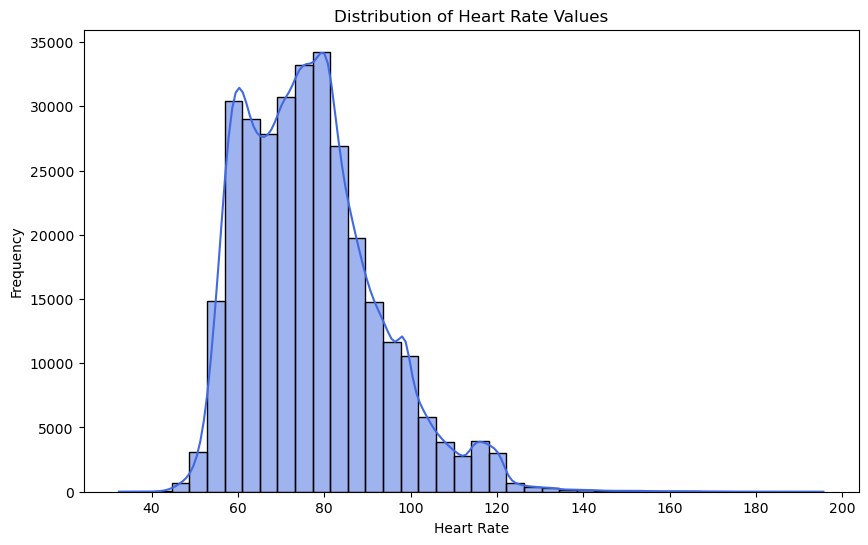

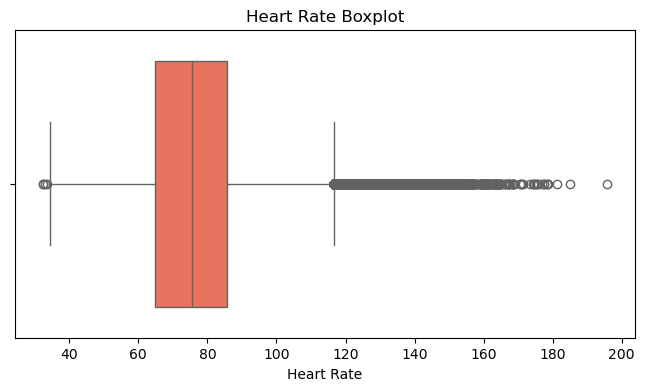

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Histogram + KDE ---
plt.figure(figsize=(10,6))
sns.histplot(df['Heart_Rate'], kde=True, bins=40, color='royalblue')
plt.title('Distribution of Heart Rate Values')
plt.xlabel('Heart Rate')
plt.ylabel('Frequency')
plt.show()

# --- 2. Boxplot ---
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Heart_Rate'], color='tomato')
plt.title('Heart Rate Boxplot')
plt.xlabel('Heart Rate')
plt.show()

### Minimum heart rate →
#### - Detects bradycardia, sleep depth, or device errors
#### - A very low minimum HR may indicate: Deep sleep,High fitness,Bradycardia,Sensor dropouts.
  
#### If the minimum is too low, it may signal a clinical red flag.

### Maximum heart rate → 
#### - Detects tachycardia, stress, or activity spikes.
#### - A high maximum HR may reflect:Exercise,Stress,Fever,Anxiety,Arrhythmia,Device noise.

#### If the max is extremely high, it may require follow‑up.

### Mean heart rate → 
#### - Overall cardiovascular load.
#### - The mean HR is a powerful indicator of:Fitness level,Stress load,Autonomic balance,Cardiovascular risk.

#### A high mean HR is associated with higher long‑term mortality risk in clinical literature.

### Median heart rate → 
#### - Robust central tendency
#### - The median tells you the “typical” HR without being distorted by spikes.
#### - If mean ≠ median, the distribution is skewed, which means:Many spikes,Many dips,High variability,Possible sensor noise.

#### This helps you decide whether to use mean‑based or median‑based metrics.